# **Credit Risk Scoring — Probabilidad de Impago (PD)**
### Comparación de LPM, Logit y Probit

La **Probabilidad de Impago** (*Probability of Default*, PD) es el pilar central de cualquier modelo de riesgo de crédito: estima, para cada solicitante, la probabilidad de que incumpla sus obligaciones de pago.

En este notebook estimamos la PD con tres enfoques econométricos clásicos para variables dependientes binarias:

| Modelo | Función de enlace | Rango de la predicción |
|---|---|---|
| **LPM** (Linear Probability Model) | Identidad | $(-\infty, +\infty)$ — puede salir de $[0,1]$ |
| **Logit** | Logística | $(0, 1)$ |
| **Probit** | Normal estándar (CDF) | $(0, 1)$ |

$$
\Large P(Y_i=1 \mid X_i) = \begin{cases}
X_i'\beta & \text{LPM (OLS)}\\[4pt]
\dfrac{e^{X_i'\beta}}{1+e^{X_i'\beta}} & \text{Logit}\\[4pt]
\Phi(X_i'\beta) & \text{Probit}
\end{cases}
$$

**Dataset:** usamos el dataset *German Credit* — idéntico al dataset [`credit-g`](https://www.openml.org/d/31) de OpenML (ID 31, 1000 solicitantes, 20 atributos + variable objetivo `good`/`bad`). En este entorno de ejecución no hay salida de red hacia `openml.org`, así que lo cargamos localmente vía la librería `scorecardpy` (misma fuente de datos: UCI/Statlog German Credit). Si ejecutas este notebook con acceso a internet, puedes obtener exactamente los mismos datos con:

```python
from sklearn.datasets import fetch_openml
data = fetch_openml("credit-g", version=1, as_frame=True)
```

## Librerías usadas

In [1]:
# Manipulación de datos
import pandas as pd
import numpy as np

# Modelos econométricos (LPM vía OLS, Logit, Probit)
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Métricas de clasificación
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, roc_auc_score, confusion_matrix, classification_report

# Dataset German Credit (equivalente a OpenML credit-g, ID 31)
import scorecardpy as sc

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
sns.set_palette("viridis")

import warnings
warnings.simplefilter(action="ignore", category=FutureWarning)
warnings.simplefilter(action="ignore", category=UserWarning)

%matplotlib inline

## Carga de Datos

Cargamos el dataset y definimos la variable objetivo `default`: 1 si el cliente es `bad` (impago), 0 si es `good`.

In [2]:
raw = sc.germancredit()
raw["default"] = (raw["creditability"] == "bad").astype(int)

print(f"Observaciones: {raw.shape[0]} | Atributos: {raw.shape[1] - 1}")
raw.head(3)

Observaciones: 1000 | Atributos: 21


,status_of_existing_checking_account,duration_in_month,credit_history,purpose,credit_amount,savings_account_and_bonds,present_employment_since,installment_rate_in_percentage_of_disposable_income,personal_status_and_sex,other_debtors_or_guarantors,...,age_in_years,other_installment_plans,housing,number_of_existing_credits_at_this_bank,job,number_of_people_being_liable_to_provide_maintenance_for,telephone,foreign_worker,creditability,default
0,... < 0 DM,6,critical account/ other credits existing (not ...,radio/television,1169,unknown/ no savings account,... >= 7 years,4,male : divorced/separated,none,...,67,none,own,2,skilled employee / official,1,"yes, registered under the customers name",yes,good,0
1,0 <= ... < 200 DM,48,existing credits paid back duly till now,radio/television,5951,... < 100 DM,1 <= ... < 4 years,2,male : divorced/separated,none,...,22,none,own,1,skilled employee / official,1,none,yes,bad,1
2,no checking account,12,critical account/ other credits existing (not ...,education,2096,... < 100 DM,4 <= ... < 7 years,2,male : divorced/separated,none,...,49,none,own,1,unskilled - resident,2,none,yes,good,0


### Balance de clases

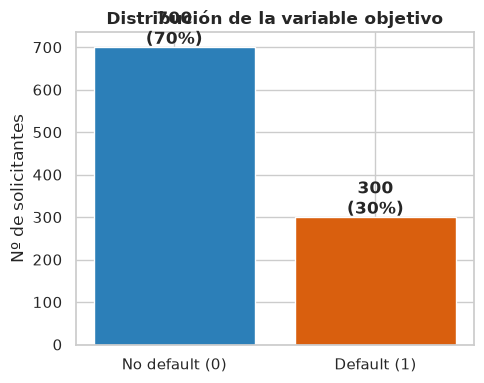

In [3]:
fig, ax = plt.subplots(figsize=(5, 4))
counts = raw["default"].value_counts().sort_index()
ax.bar(["No default (0)", "Default (1)"], counts.values, color=["#2c7fb8", "#d95f0e"])
for i, v in enumerate(counts.values):
    ax.text(i, v + 8, f"{v}\n({v/len(raw):.0%})", ha="center", fontweight="bold")
ax.set_title("Distribución de la variable objetivo", fontweight="bold")
ax.set_ylabel("Nº de solicitantes")
plt.tight_layout()
plt.show()

## Análisis Exploratorio

Comparamos algunas variables numéricas y categóricas clave entre clientes que incumplen (`default = 1`) y los que no.

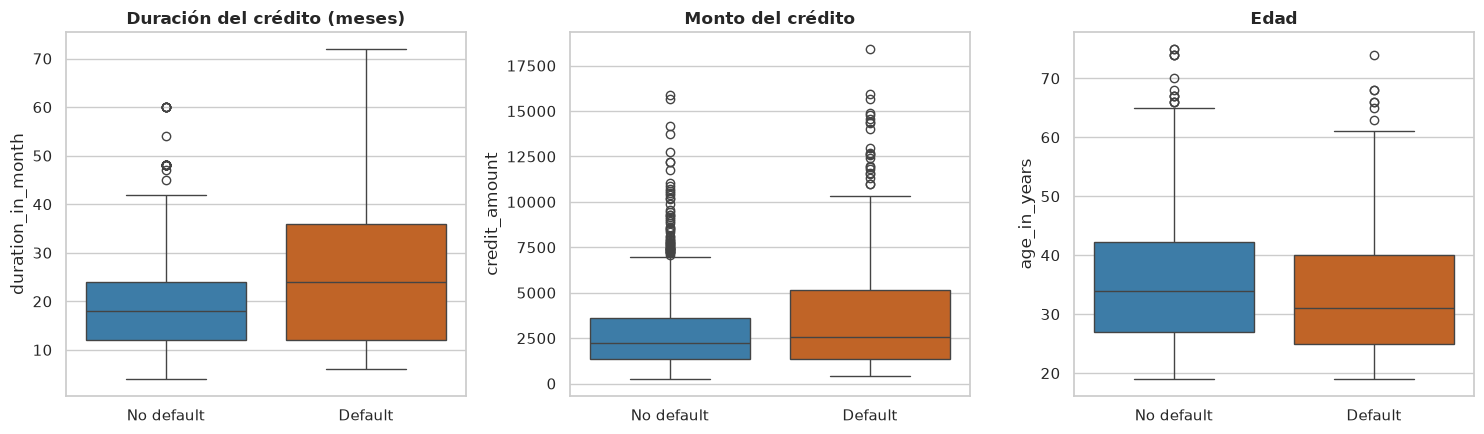

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for ax, col, title in zip(
    axes,
    ["duration_in_month", "credit_amount", "age_in_years"],
    ["Duración del crédito (meses)", "Monto del crédito", "Edad"],
):
    sns.boxplot(data=raw, x="default", y=col, hue="default", ax=ax, palette=["#2c7fb8", "#d95f0e"], legend=False)
    ax.set_title(title, fontweight="bold")
    ax.set_xticklabels(["No default", "Default"])
    ax.set_xlabel("")

plt.tight_layout()
plt.show()

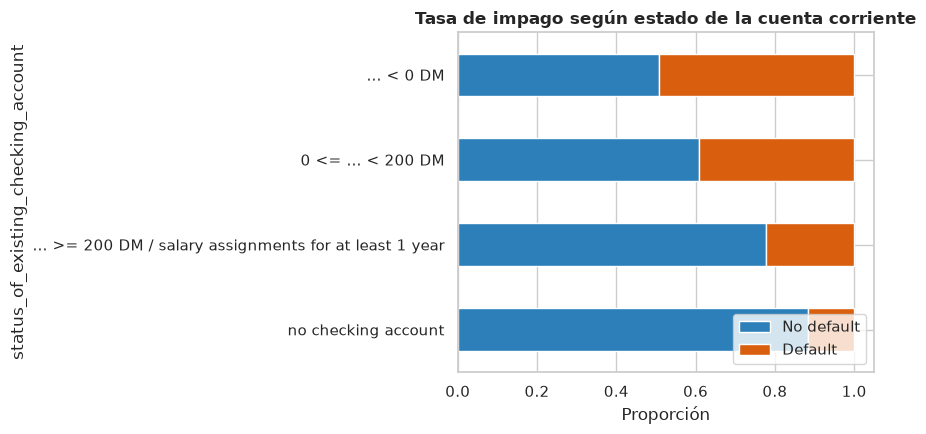

In [5]:
fig, ax = plt.subplots(figsize=(9, 4.5))
tab = pd.crosstab(raw["status_of_existing_checking_account"], raw["default"], normalize="index")
tab.columns = ["No default", "Default"]
tab.sort_values("Default").plot(kind="barh", stacked=True, ax=ax, color=["#2c7fb8", "#d95f0e"])
ax.set_title("Tasa de impago según estado de la cuenta corriente", fontweight="bold")
ax.set_xlabel("Proporción")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

## Preprocesamiento

Seleccionamos un conjunto parsimonioso de predictores —numéricos y categóricos— clásicos en la literatura de credit scoring, codificamos las variables categóricas con *dummies* ($k-1$ categorías) y dividimos en entrenamiento (70%) y prueba (30%), estratificando por la variable objetivo.

In [6]:
num_features = ["duration_in_month", "credit_amount",
                "installment_rate_in_percentage_of_disposable_income", "age_in_years"]

cat_features = ["status_of_existing_checking_account", "credit_history",
                "savings_account_and_bonds", "housing", "foreign_worker"]

X = pd.get_dummies(raw[num_features + cat_features], columns=cat_features, drop_first=True)
X = X.astype(float)
y = raw["default"].astype(float)

print(f"Predictores tras codificación: {X.shape[1]}")
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42
)
print(f"Entrenamiento: {X_train.shape[0]} | Prueba: {X_test.shape[0]}")

Predictores tras codificación: 18
Entrenamiento: 700 | Prueba: 300


## Modelo 1 — Linear Probability Model (LPM)

El LPM estima la PD directamente por **Mínimos Cuadrados Ordinarios (OLS)**, tratando la variable binaria como si fuera continua:

$$
\Large P(default_i = 1) = \beta_0 + \beta_1 X_{1i} + \dots + \beta_k X_{ki} + \varepsilon_i
$$

**Problema conocido:** los errores son heterocedásticos por construcción ($Var(\varepsilon_i) = p_i(1-p_i)$ varía con $X_i$), por lo que reportamos errores estándar robustos (HC3). Además, nada impide que $\hat{p}_i$ caiga fuera de $[0,1]$.

In [7]:
X_train_c = sm.add_constant(X_train)
X_test_c = sm.add_constant(X_test, has_constant="add")

lpm = sm.OLS(y_train, X_train_c).fit(cov_type="HC3")
print(lpm.summary().tables[0])

                            OLS Regression Results                            
Dep. Variable:                default   R-squared:                       0.212
Model:                            OLS   Adj. R-squared:                  0.191
Method:                 Least Squares   F-statistic:                     13.12
Date:                Tue, 29 Sep 2026   Prob (F-statistic):           9.69e-34
Time:                        18:13:39   Log-Likelihood:                -363.67
No. Observations:                 700   AIC:                             765.3
Df Residuals:                     681   BIC:                             851.8
Df Model:                          18                                         
Covariance Type:                  HC3                                         


Predicciones fuera de [0,1]: 6.7%


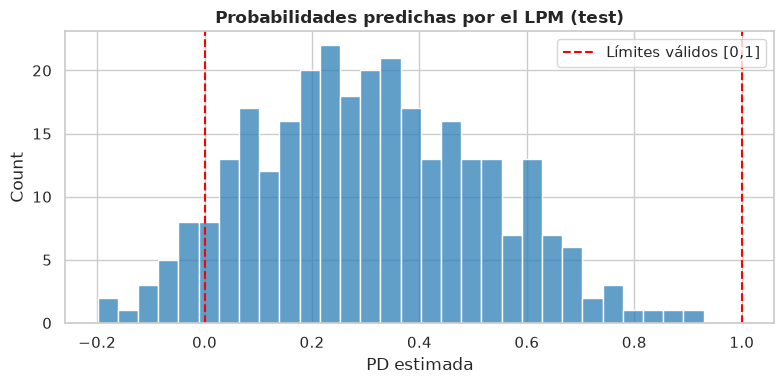

In [8]:
pred_lpm_test = lpm.predict(X_test_c)

fuera_de_rango = ((pred_lpm_test < 0) | (pred_lpm_test > 1)).mean()
print(f"Predicciones fuera de [0,1]: {fuera_de_rango:.1%}")

fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(pred_lpm_test, bins=30, color="#2c7fb8", ax=ax)
ax.axvline(0, color="red", ls="--", lw=1.5)
ax.axvline(1, color="red", ls="--", lw=1.5, label="Límites válidos [0,1]")
ax.set_title("Probabilidades predichas por el LPM (test)", fontweight="bold")
ax.set_xlabel("PD estimada")
ax.legend()
plt.tight_layout()
plt.show()

## Modelo 2 — Logit

El modelo Logit garantiza $\hat{p}_i \in (0,1)$ modelando el **log-odds** de forma lineal, estimado por Máxima Verosimilitud (MLE):

$$
\Large \ln\left(\frac{p_i}{1-p_i}\right) = X_i'\beta \quad\Longrightarrow\quad p_i = \frac{e^{X_i'\beta}}{1+e^{X_i'\beta}}
$$

Los coeficientes se interpretan en términos de **odds ratios**: $e^{\beta_j}$ es el factor multiplicativo sobre el *odds* de impago ante un incremento unitario de $X_j$.

In [9]:
logit = sm.Logit(y_train, X_train_c).fit(disp=False)
print(logit.summary().tables[0])

                           Logit Regression Results                           
Dep. Variable:                default   No. Observations:                  700
Model:                          Logit   Df Residuals:                      681
Method:                           MLE   Df Model:                           18
Date:                Tue, 29 Sep 2026   Pseudo R-squ.:                  0.1952
Time:                        18:13:39   Log-Likelihood:                -344.16
converged:                       True   LL-Null:                       -427.61
Covariance Type:            nonrobust   LLR p-value:                 3.698e-26


In [10]:
odds_ratios = pd.DataFrame({
    "coef": logit.params,
    "odds_ratio": np.exp(logit.params),
    "p_valor": logit.pvalues,
}).sort_values("p_valor")

odds_ratios.head(10).style.format({"coef": "{:.3f}", "odds_ratio": "{:.3f}", "p_valor": "{:.3f}"})

,coef,odds_ratio,p_valor
status_of_existing_checking_account_no checking account,-1.625,0.197,0.000
savings_account_and_bonds_unknown/ no savings account,-1.048,0.351,0.001
credit_history_critical account/ other credits existing (not at this bank),-1.469,0.230,0.002
housing_own,-0.692,0.501,0.005
installment_rate_in_percentage_of_disposable_income,0.260,1.297,0.007
duration_in_month,0.025,1.026,0.018
savings_account_and_bonds_... >= 1000 DM,-1.160,0.313,0.031
foreign_worker_no,-1.616,0.199,0.041
status_of_existing_checking_account_... >= 200 DM / salary assignments for at least 1 year,-0.727,0.483,0.066
credit_history_existing credits paid back duly till now,-0.827,0.437,0.068


## Modelo 3 — Probit

El Probit usa la función de distribución acumulada de la normal estándar $\Phi(\cdot)$ como enlace:

$$
\Large p_i = \Phi(X_i'\beta)
$$

En la práctica, Logit y Probit suelen producir predicciones casi idénticas — difieren principalmente en la escala de los coeficientes (los del Probit son aprox. $1/1.6$ veces los del Logit), no en la forma funcional resultante.

In [11]:
probit = sm.Probit(y_train, X_train_c).fit(disp=False)
print(probit.summary().tables[0])

                          Probit Regression Results                           
Dep. Variable:                default   No. Observations:                  700
Model:                         Probit   Df Residuals:                      681
Method:                           MLE   Df Model:                           18
Date:                Tue, 29 Sep 2026   Pseudo R-squ.:                  0.1948
Time:                        18:13:39   Log-Likelihood:                -344.29
converged:                       True   LL-Null:                       -427.61
Covariance Type:            nonrobust   LLR p-value:                 4.182e-26


## Comparación de Coeficientes y Efectos Marginales

Los coeficientes crudos de Logit y Probit no son directamente comparables entre sí ni con el LPM porque viven en escalas distintas (log-odds vs. z-score vs. probabilidad). Para comparar los tres modelos en las mismas unidades, calculamos los **efectos marginales promedio (AME)**: el cambio en la PD ante un incremento unitario de cada regresor, promediado sobre la muestra.

In [12]:
ame_logit = logit.get_margeff(at="overall").summary_frame()["dy/dx"]
ame_probit = probit.get_margeff(at="overall").summary_frame()["dy/dx"]
coef_lpm = lpm.params.drop("const")

comparacion = pd.DataFrame({
    "LPM (coef. = efecto marginal)": coef_lpm,
    "Logit (efecto marginal medio)": ame_logit,
    "Probit (efecto marginal medio)": ame_probit,
})

top_vars = comparacion.abs().mean(axis=1).sort_values(ascending=False).head(10).index
comparacion.loc[top_vars].style.format("{:.4f}").background_gradient(cmap="RdBu_r", axis=None)

,LPM (coef. = efecto marginal),Logit (efecto marginal medio),Probit (efecto marginal medio)
status_of_existing_checking_account_no checking account,-0.2779,-0.2644,-0.2658
credit_history_critical account/ other credits existing (not at this bank),-0.2738,-0.2391,-0.2523
foreign_worker_no,-0.1619,-0.2631,-0.2452
savings_account_and_bonds_... >= 1000 DM,-0.1556,-0.1888,-0.1769
savings_account_and_bonds_unknown/ no savings account,-0.1532,-0.1705,-0.1590
credit_history_existing credits paid back duly till now,-0.1755,-0.1346,-0.1475
credit_history_delay in paying off in the past,-0.1733,-0.1274,-0.1346
status_of_existing_checking_account_... >= 200 DM / salary assignments for at least 1 year,-0.1471,-0.1183,-0.1165
savings_account_and_bonds_500 <= ... < 1000 DM,-0.1187,-0.1224,-0.1129
housing_own,-0.1217,-0.1126,-0.1108


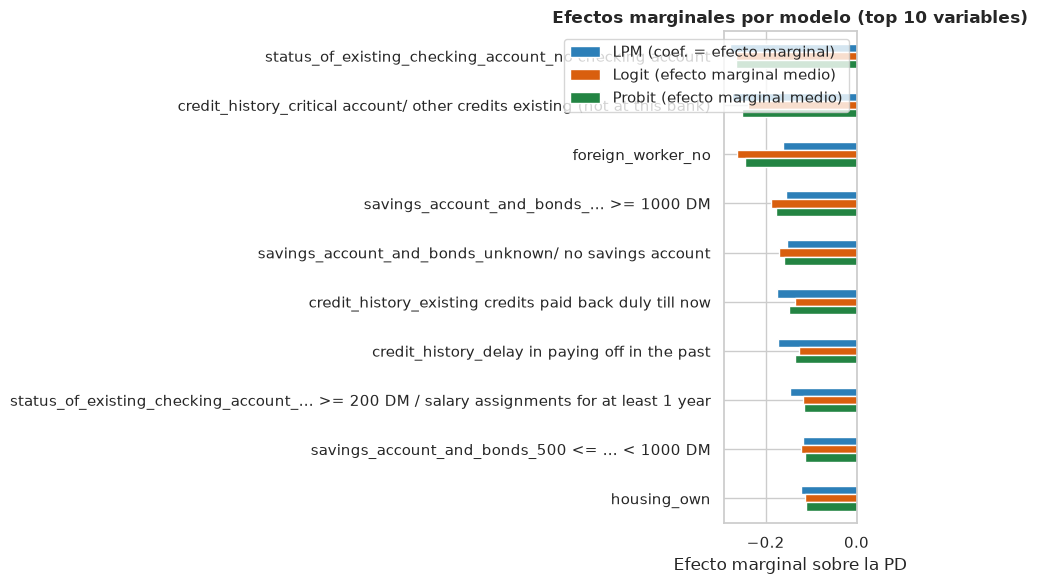

In [13]:
fig, ax = plt.subplots(figsize=(9, 6))
comparacion.loc[top_vars].plot(kind="barh", ax=ax, color=["#2c7fb8", "#d95f0e", "#238443"])
ax.set_title("Efectos marginales por modelo (top 10 variables)", fontweight="bold")
ax.set_xlabel("Efecto marginal sobre la PD")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## Predicciones Fuera de Muestra

Comparamos las probabilidades predichas por los tres modelos sobre el conjunto de prueba. Como es habitual, Logit y Probit son casi indistinguibles entre sí; el LPM se aparta más, especialmente en los extremos.

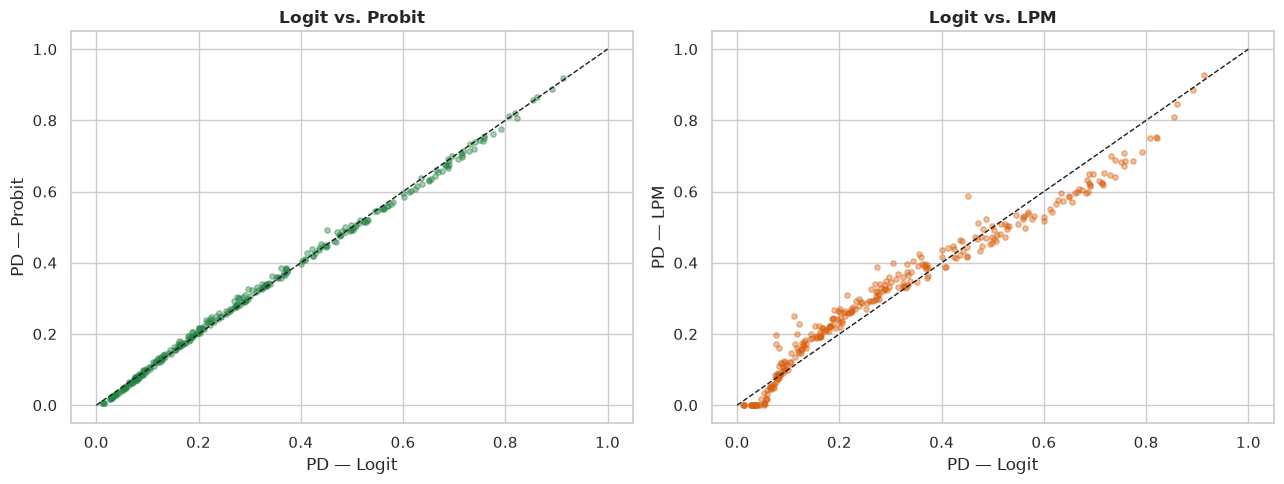

,LPM,Logit,Probit
LPM,1.0000,0.9820,0.9874
Logit,0.9820,1.0000,0.9991
Probit,0.9874,0.9991,1.0000


In [14]:
pred_lpm = lpm.predict(X_test_c).clip(0, 1)
pred_logit = logit.predict(X_test_c)
pred_probit = probit.predict(X_test_c)

preds = pd.DataFrame({"LPM": pred_lpm, "Logit": pred_logit, "Probit": pred_probit})

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(preds["Logit"], preds["Probit"], alpha=0.4, color="#238443", s=15)
axes[0].plot([0, 1], [0, 1], "k--", lw=1)
axes[0].set_xlabel("PD — Logit")
axes[0].set_ylabel("PD — Probit")
axes[0].set_title("Logit vs. Probit", fontweight="bold")

axes[1].scatter(preds["Logit"], preds["LPM"], alpha=0.4, color="#d95f0e", s=15)
axes[1].plot([0, 1], [0, 1], "k--", lw=1)
axes[1].set_xlabel("PD — Logit")
axes[1].set_ylabel("PD — LPM")
axes[1].set_title("Logit vs. LPM", fontweight="bold")

plt.tight_layout()
plt.show()

preds.corr().style.format("{:.4f}")

## Evaluación: Curvas ROC y AUC

El **AUC (Area Under the Curve)** mide la capacidad discriminante del modelo — qué tan bien separa a los clientes que incumplen de los que no, independientemente del umbral de decisión elegido.

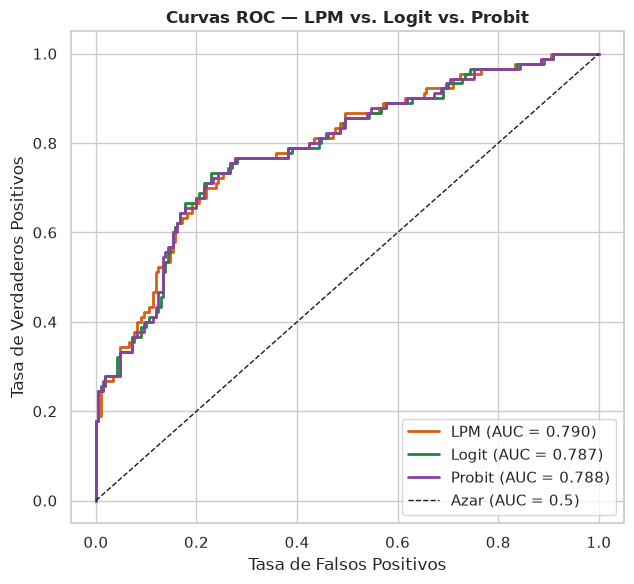

In [15]:
fig, ax = plt.subplots(figsize=(6.5, 6))
colors = {"LPM": "#d95f0e", "Logit": "#238443", "Probit": "#88419d"}

for name, pred in preds.items():
    fpr, tpr, _ = roc_curve(y_test, pred)
    auc = roc_auc_score(y_test, pred)
    ax.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})", color=colors[name], lw=2)

ax.plot([0, 1], [0, 1], "k--", lw=1, label="Azar (AUC = 0.5)")
ax.set_xlabel("Tasa de Falsos Positivos")
ax.set_ylabel("Tasa de Verdaderos Positivos")
ax.set_title("Curvas ROC — LPM vs. Logit vs. Probit", fontweight="bold")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

## Matriz de Confusión y Métricas de Clasificación

Clasificamos como *default* toda predicción con PD $\geq 0.5$ y comparamos el desempeño de los tres modelos con las mismas reglas de decisión.

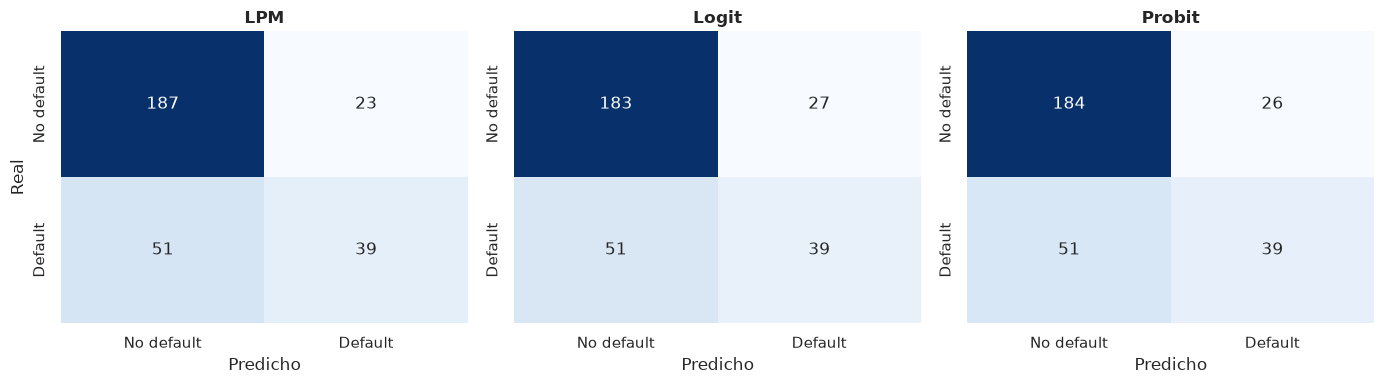

,AUC,Accuracy,Precision (default),Recall (default),F1 (default)
Modelo,,,,,
LPM,0.790,0.753,0.629,0.433,0.513
Logit,0.787,0.740,0.591,0.433,0.500
Probit,0.788,0.743,0.600,0.433,0.503


In [16]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

metricas = []
for ax, (name, pred) in zip(axes, preds.items()):
    y_pred = (pred >= 0.5).astype(int)
    cm = confusion_matrix(y_test.astype(int), y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
                xticklabels=["No default", "Default"], yticklabels=["No default", "Default"])
    ax.set_title(name, fontweight="bold")
    ax.set_xlabel("Predicho")
    ax.set_ylabel("Real" if name == "LPM" else "")

    report = classification_report(y_test.astype(int), y_pred, output_dict=True)
    metricas.append({
        "Modelo": name,
        "AUC": roc_auc_score(y_test, pred),
        "Accuracy": report["accuracy"],
        "Precision (default)": report["1"]["precision"],
        "Recall (default)": report["1"]["recall"],
        "F1 (default)": report["1"]["f1-score"],
    })

plt.tight_layout()
plt.show()

metricas_df = pd.DataFrame(metricas).set_index("Modelo")
metricas_df.style.format("{:.3f}").background_gradient(cmap="Greens", axis=0)

## Calibración del Modelo

Un buen modelo de PD no solo debe discriminar (AUC alto), sino estar **bien calibrado**: entre los clientes con PD predicha de, por ejemplo, 30%, aproximadamente el 30% debería incumplir realmente.

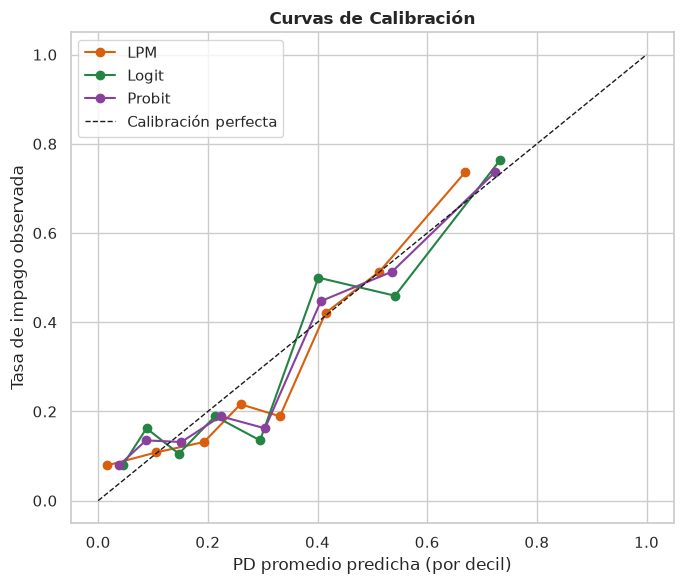

In [17]:
fig, ax = plt.subplots(figsize=(7, 6))

for name, pred in preds.items():
    bins = pd.qcut(pred, q=8, duplicates="drop")
    calib = pd.DataFrame({"pred": pred, "real": y_test.values, "bin": bins}).groupby("bin", observed=True).mean(numeric_only=True)
    ax.plot(calib["pred"], calib["real"], marker="o", label=name, color=colors[name])

ax.plot([0, 1], [0, 1], "k--", lw=1, label="Calibración perfecta")
ax.set_xlabel("PD promedio predicha (por decil)")
ax.set_ylabel("Tasa de impago observada")
ax.set_title("Curvas de Calibración", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

## Conclusiones

- **LPM**: es el más simple de estimar e interpretar (los coeficientes SON el efecto marginal directamente), pero produce predicciones fuera de $[0,1]$ y errores heterocedásticos por construcción. Útil como *benchmark* rápido, no recomendable como modelo final de producción.
- **Logit y Probit**: prácticamente indistinguibles en AUC, calibración y matriz de confusión — la elección entre ambos suele ser una cuestión de convención (Logit domina en la industria de credit scoring por la interpretación directa en *odds ratios* y su relación natural con el *scorecard* logístico estándar).
- **Efectos marginales**: el estado de la cuenta corriente (`status_of_existing_checking_account`), el historial de crédito (`credit_history`) y la duración del préstamo (`duration_in_month`) son los predictores con mayor efecto sobre la PD, consistente con la intuición de negocio.
- **Calibración**: Logit y Probit se mantienen razonablemente cerca de la diagonal de calibración perfecta; el LPM tiende a desviarse más en los extremos, coherente con el hecho de que no está diseñado para producir probabilidades acotadas.
- **Recomendación práctica**: para un modelo de PD en producción, Logit es el punto de partida estándar de la industria — es la base de la mayoría de *scorecards* de crédito (frecuentemente combinado con *Weight of Evidence* (WOE) sobre las variables, como hace por ejemplo la librería `scorecardpy` usada aquí para cargar los datos).